In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
#load and Explore the Raw Data
df = pd.read_excel("cost_prediction.xlsx")
print("Dataset shape:", df.shape)
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
df.head()

Dataset shape: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [3]:
#Data Cleaning
df_clean = df.dropna(subset=["CustomerID"]).copy()
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
df_clean = df_clean[
    (df_clean["Quantity"] > 0) & 
    (df_clean["UnitPrice"] > 0)
    ]
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
df_clean.head()

Original shape: (541909, 8)
Cleaned shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [4]:
customer_data = df_clean.groupby("CustomerID").agg(
    TotalSpent=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    TotalTransactions=("InvoiceNo", "nunique"),
    AveragePrice=("UnitPrice", "mean")
).reset_index()

print("Customer data shape:", customer_data.shape)
customer_data.describe()

Customer data shape: (4338, 5)


,CustomerID,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice
count,"4,338.00","4,338.00","4,338.00","4,338.00","4,338.00"
mean,"15,300.41","2,054.27","1,191.29",4.27,4.47
std,"1,721.81","8,989.23","5,046.08",7.70,34.21
min,"12,346.00",3.75,1.00,1.00,0.12
25%,"13,813.25",307.41,160.00,1.00,2.20
50%,"15,299.50",674.49,379.00,2.00,2.92
75%,"16,778.75","1,661.74",992.75,5.00,3.83
max,"18,287.00","280,206.02","196,915.00",209.00,"2,033.10"


In [5]:
#Outlier Removal
features = ["TotalSpent", "TotalQuantity", "TotalTransactions", "AveragePrice"]
mask = pd.Series(True, index=customer_data.index)
for column in features:
    upper_limit = customer_data[column].quantile(0.99)
    mask &= customer_data[column] <= upper_limit
    
customer_filtered = customer_data[mask].copy()
print("Before removing outliers:", customer_data.shape)
print("After removing outliers:", customer_filtered.shape)

Before removing outliers: (4338, 5)
After removing outliers: (4228, 5)


In [6]:
#Feature Scaling
X = customer_filtered[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.52130228,  1.45406009,  0.83022338, -0.35068422],
       [ 0.22836068,  1.35166292,  0.07857789,  1.58193606],
       [ 0.20793818, -0.14491114, -0.67306761,  3.14508697],
       [-0.52434418, -0.52474338, -0.67306761,  0.39067881],
       [-0.65061484, -0.67965193, -0.67306761,  1.77400818]])

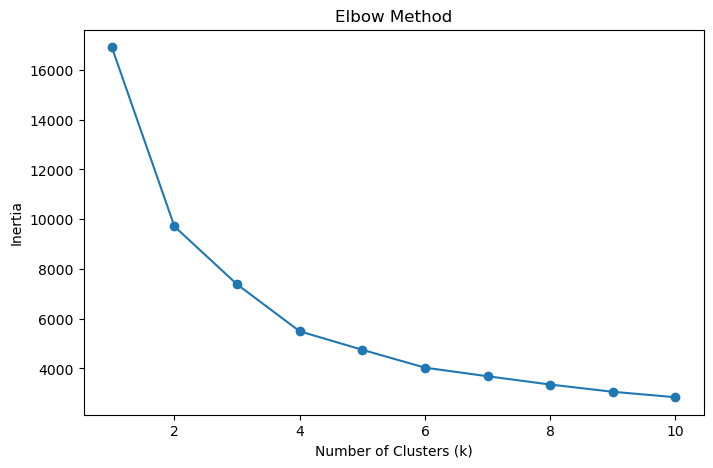

In [7]:
#Using K-Elbow Method
inertia = []
k_range = range(1, 11)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)
    
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [8]:
#Final KMeans Model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_filtered["Cluster"] = kmeans.fit_predict(X_scaled)
print(customer_filtered["Cluster"].value_counts().sort_index())
customer_filtered.head()

Cluster
0     174
1    2654
2     639
3     761
Name: count, dtype: int64


,CustomerID,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice,Cluster
1,12347,"4,310.00",2458,7,2.64,3
2,12348,"1,797.24",2341,4,5.76,2
3,12349,"1,757.55",631,1,8.29,2
4,12350,334.40,197,1,3.84,1
6,12353,89.00,20,1,6.07,2


In [9]:
#Cluster Profiling
cluster_summary = customer_filtered.groupby("Cluster")[features].mean().round(2)
cluster_summary

,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice
Cluster,,,,
0,"8,308.10","4,812.96",15.83,2.97
1,613.34,393.38,2.13,2.63
2,674.74,247.78,2.20,5.99
3,"2,914.25","1,745.21",7.59,2.96


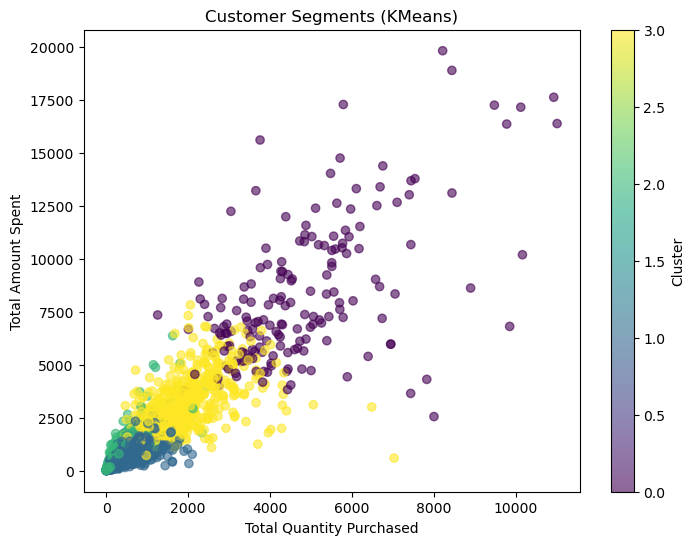

In [10]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    customer_filtered["TotalQuantity"],
    customer_filtered["TotalSpent"],
    c=customer_filtered["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Total Quantity Purchased")
plt.ylabel("Total Amount Spent")
plt.title("Customer Segments (KMeans)")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [11]:
spending_order = cluster_summary["TotalSpent"].sort_values().index.tolist()
cluster_names = {
    spending_order[0]: "Low Value Customer",
    spending_order[1]: "Regular Customer",
    spending_order[2]: "High Value Customer",
    spending_order[3]: "Premium Customer"
}

customer_filtered["CustomerType"] = customer_filtered["Cluster"].map(cluster_names)
customer_filtered[[
    "CustomerID", "TotalSpent", "TotalQuantity",
    "TotalTransactions", "AveragePrice", "Cluster", "CustomerType"
]].head(10)

,CustomerID,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice,Cluster,CustomerType
1,12347,"4,310.00",2458,7,2.64,3,High Value Customer
2,12348,"1,797.24",2341,4,5.76,2,Regular Customer
3,12349,"1,757.55",631,1,8.29,2,Regular Customer
4,12350,334.40,197,1,3.84,1,Low Value Customer
6,12353,89.00,20,1,6.07,2,Regular Customer
7,12354,"1,079.40",530,1,4.50,2,Regular Customer
8,12355,459.40,240,1,4.20,1,Low Value Customer
9,12356,"2,811.43",1591,3,3.20,3,High Value Customer
10,12357,"6,207.67",2708,1,3.35,3,High Value Customer
11,12358,"1,168.06",248,2,8.27,2,Regular Customer


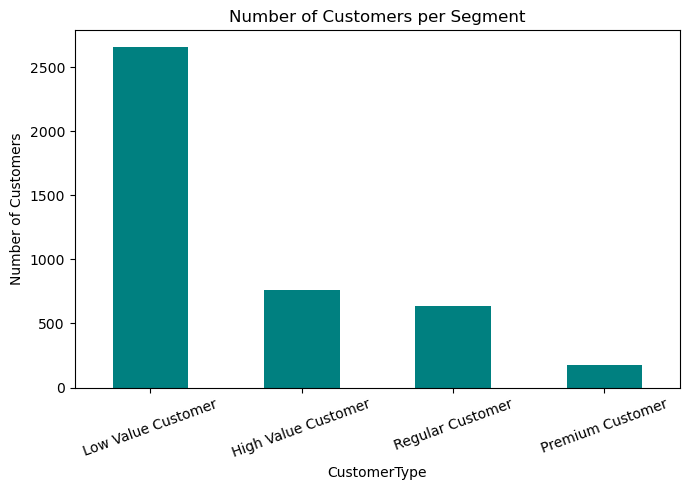

CustomerType
Low Value Customer     2654
High Value Customer     761
Regular Customer        639
Premium Customer        174
Name: count, dtype: int64

In [12]:
counts = customer_filtered["CustomerType"].value_counts()

plt.figure(figsize=(7, 5))
counts.plot(kind="bar", color="teal")
plt.title("Number of Customers per Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

counts

In [13]:
np.random.seed(42)

n_samples = X_scaled.shape[0]
shuffled_indices = np.random.permutation(n_samples)

split_point = int(n_samples * 0.8)
train_idx = shuffled_indices[:split_point]
test_idx = shuffled_indices[split_point:]

X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train = customer_filtered["Cluster"].values[train_idx]
y_test = customer_filtered["Cluster"].values[test_idx]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3382
Testing samples: 846


In [14]:
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
# Accuracy calculation - fraction of correct predictions
accuracy = (y_pred == y_test).mean()
print("Test Accuracy:", round(accuracy, 4))
# Confusion matrix using pandas
comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
pd.crosstab(comparison["Actual"], comparison["Predicted"], rownames=["Actual"], colnames=["Predicted"])

Test Accuracy: 0.9858


Predicted,0,1,2,3
Actual,,,,
0,37,0,0,4
1,0,518,0,3
2,0,0,127,0
3,3,1,1,152


In [15]:
def predict_customer_type(total_spent, total_quantity, total_transactions, average_price):
    new_customer = pd.DataFrame([{
        "TotalSpent": total_spent,
        "TotalQuantity": total_quantity,
        "TotalTransactions": total_transactions,
        "AveragePrice": average_price
    }])
    new_customer_scaled = scaler.transform(new_customer)
    predicted_cluster = clf.predict(new_customer_scaled)[0]
    return predicted_cluster, cluster_names[predicted_cluster]

# Demo with a few sample customers
sample_customers = [
    {"total_spent": 150, "total_quantity": 60, "total_transactions": 1, "average_price": 2.5},
    {"total_spent": 1800, "total_quantity": 900, "total_transactions": 6, "average_price": 3.0},
    {"total_spent": 7000, "total_quantity": 4200, "total_transactions": 15, "average_price": 2.9},
]

for cust in sample_customers:
    cluster_id, cust_type = predict_customer_type(**cust)
    print(cust, "->", f"Cluster {cluster_id}", "-", cust_type)

{'total_spent': 150, 'total_quantity': 60, 'total_transactions': 1, 'average_price': 2.5} -> Cluster 1 - Low Value Customer
{'total_spent': 1800, 'total_quantity': 900, 'total_transactions': 6, 'average_price': 3.0} -> Cluster 3 - High Value Customer
{'total_spent': 7000, 'total_quantity': 4200, 'total_transactions': 15, 'average_price': 2.9} -> Cluster 0 - Premium Customer


In [ ]:
total_spent = float(input("Enter Total Amount Spent: "))
total_quantity = float(input("Enter Total Quantity Purchased: "))
total_transactions = float(input("Enter Total Number of Transactions: "))
average_price = float(input("Enter Average Product Price: "))

cluster_id, cust_type = predict_customer_type(total_spent, total_quantity, total_transactions, average_price)
print("\nPredicted Cluster:", cluster_id)
print("Predicted Customer Type:", cust_type)

In [ ]:
#Predicting which Country's Sales will grow
df_trend = df_clean[df_clean["InvoiceDate"] < "2011-12-01"].copy()
df_trend["InvoiceMonth"] = df_trend["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

country_monthly = df_trend.groupby(["Country", "InvoiceMonth"])["TotalPrice"].sum().reset_index()

months_per_country = country_monthly.groupby("Country")["InvoiceMonth"].nunique()
eligible_countries = [c for c in months_per_country[months_per_country >= 6].index if c != "United Kingdom"]

print("Countries with enough history for a trend estimate:", len(eligible_countries))

In [ ]:
growth_rows = []

for country in eligible_countries:
    sub = country_monthly[country_monthly["Country"] == country].sort_values("InvoiceMonth")
    x = np.arange(len(sub)).reshape(-1, 1)
    y = sub["TotalPrice"].values
        
    lr = LinearRegression().fit(x, y)
    slope = lr.coef_[0]
    avg_monthly_revenue = y.mean()
    growth_pct = (slope / avg_monthly_revenue) * 100 if avg_monthly_revenue > 0 else 0
    growth_rows.append({
        "Country": country,
        "AvgMonthlyRevenue": avg_monthly_revenue,
        "MonthlyGrowthPct": growth_pct,
        "TotalRevenue": y.sum()
    })
    
    growth_df = pd.DataFrame(growth_rows).sort_values("MonthlyGrowthPct", ascending=False).reset_index(drop=True)
    growth_df.round(2).head(10)

In [ ]:
top_growth = growth_df.iloc[0]
print(f"Predicted fastest-growing market: {top_growth['Country']}")
print(f"Estimated monthly growth rate: {top_growth['MonthlyGrowthPct']:.1f}% per month")
print(f"Average monthly revenue: £{top_growth['AvgMonthlyRevenue']:.2f}")

In [ ]:
plt.figure(figsize=(9, 6))
top10 = growth_df.head(10).sort_values("MonthlyGrowthPct")
plt.barh(top10["Country"], top10["MonthlyGrowthPct"], color="seagreen")
plt.xlabel("Estimated Monthly Growth Rate (%)")
plt.title("Top 10 Countries by Predicted Sales Growth")
plt.tight_layout()
plt.show()

In [ ]:
top3 = growth_df.head(3)["Country"].tolist()

plt.figure(figsize=(9, 6))
for country in top3:
    sub = country_monthly[country_monthly["Country"] == country].sort_values("InvoiceMonth")
    plt.plot(sub["InvoiceMonth"], sub["TotalPrice"], marker="o", label=country)
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.title("Monthly Revenue Trend - Top 3 Growing Countries")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
#Save Final Results
customer_filtered.to_csv("customer_segmentation_results.csv", index=False)
growth_df.to_csv("country_growth_results.csv", index=False)

print("Files saved: customer_segmentation_results.csv, country_growth_results.csv")